# Libraries

In [1]:
# Import libraries for general analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Import libraries for classification and regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import SVC, SVR
from sklearn.linear_model import LogisticRegression, SGDClassifier, LinearRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, mean_squared_error
from math import sqrt

# Data

In [3]:
# Load the dataset
# Dataset downloaded from: https://www.kaggle.com/datasets/nikhil7280/weather-type-classification/data
df = pd.read_csv('data/weather_classification_data.csv')

## Описание колонок датасета
- Temperature (числовое): температура в градусах Цельсия, от экстремально низких до экстремально высоких значений.
- Humidity (числовое): процент влажности, включая значения выше 100% для введения выбросов.
- Wind Speed (числовое): скорость ветра в километрах в час, с диапазоном, включающим нереалистично высокие значения.
- Precipitation (%) (числовое): процент осадков, включая выбросы.
- Precipitation (категориальный): описание облачного покрова.
- Atmospheric Pressure (числовое): атмосферное давление в гПа, охватывающее широкий диапазон.
- UV Index (числовое): УФ-индекс, указывающий силу ультрафиолетового излучения.
- Season (категориальный): сезон, в течение которого были записаны данные.
- Visibility (km) (числовое): видимость в километрах, включая очень низкие или очень высокие значения.
- Location (категориальное): тип местоположения, где были записаны данные.
- Weather Type (категориальный): целевая переменная для классификации, указывающая тип погоды.

# EDA

In [4]:
# Display basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  object 
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  object 
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  object 
 10  Weather Type          13200 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.1+ MB


In [5]:
# Display first 10 rows
df.head(10)

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy
5,32.0,55,3.5,26.0,overcast,1010.03,2,Summer,5.0,inland,Cloudy
6,-2.0,97,8.0,86.0,overcast,990.87,1,Winter,4.0,inland,Snowy
7,3.0,85,6.0,96.0,partly cloudy,984.46,1,Winter,3.5,inland,Snowy
8,3.0,83,6.0,66.0,overcast,999.44,0,Winter,1.0,mountain,Snowy
9,28.0,74,8.5,107.0,clear,1012.13,8,Winter,7.5,coastal,Sunny


In [6]:
# Display summary statistics
df.describe()

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km)
count,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000
mean,19.127576,68.710833,9.832197,53.644394,1005.827896,4.005758,5.462917
std,17.386327,20.194248,6.908704,31.946541,37.199589,3.856600,3.371499
min,-25.000000,20.000000,0.000000,0.000000,800.120000,0.000000,0.000000
25%,4.000000,57.000000,5.000000,19.000000,994.800000,1.000000,3.000000
50%,21.000000,70.000000,9.000000,58.000000,1007.650000,3.000000,5.000000
75%,31.000000,84.000000,13.500000,82.000000,1016.772500,7.000000,7.500000
max,109.000000,109.000000,48.500000,109.000000,1199.210000,14.000000,20.000000


In [7]:
# Check for missing values
df.isnull().sum()

Temperature             0
Humidity                0
Wind Speed              0
Precipitation (%)       0
Cloud Cover             0
Atmospheric Pressure    0
UV Index                0
Season                  0
Visibility (km)         0
Location                0
Weather Type            0
dtype: int64

# Vizualization

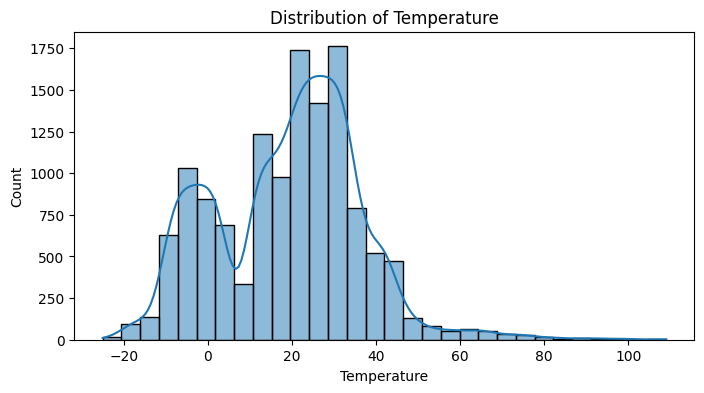

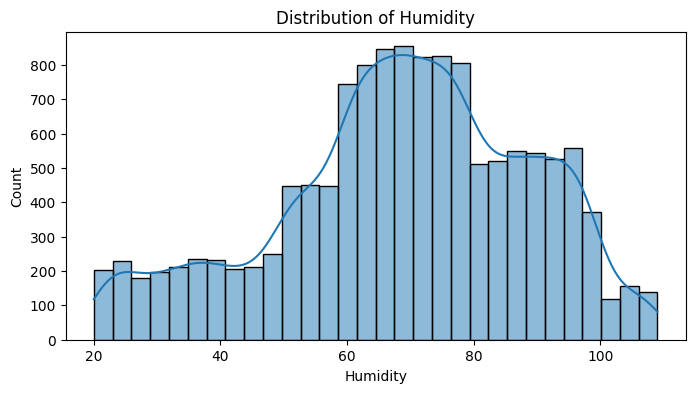

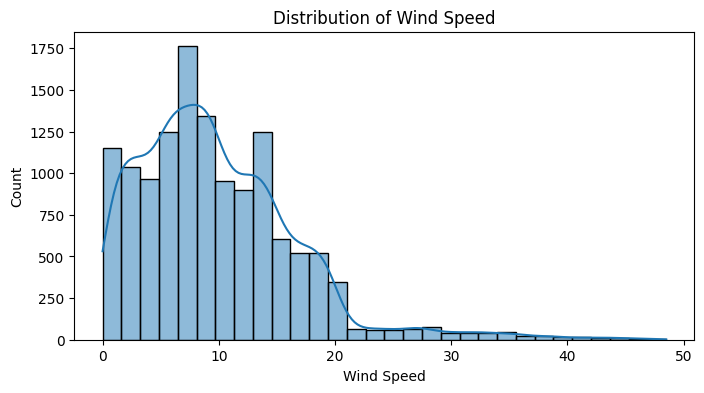

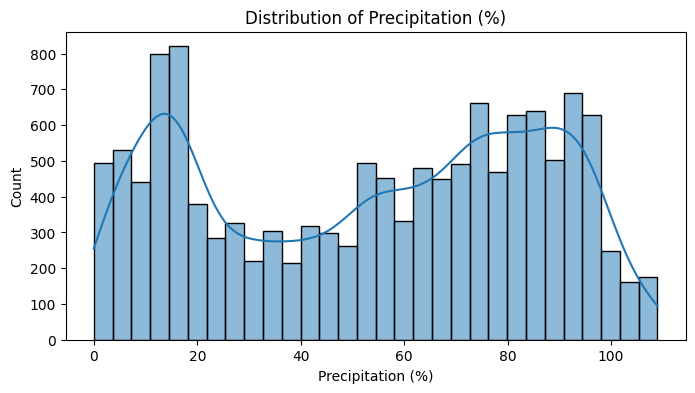

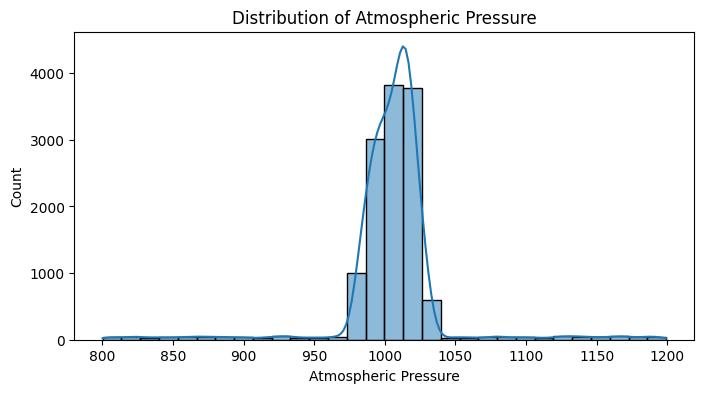

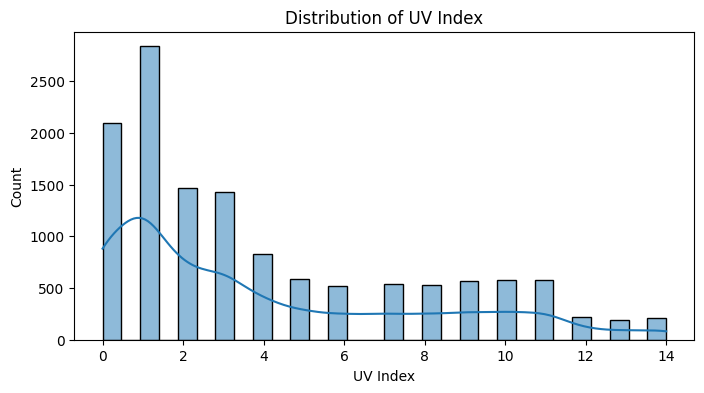

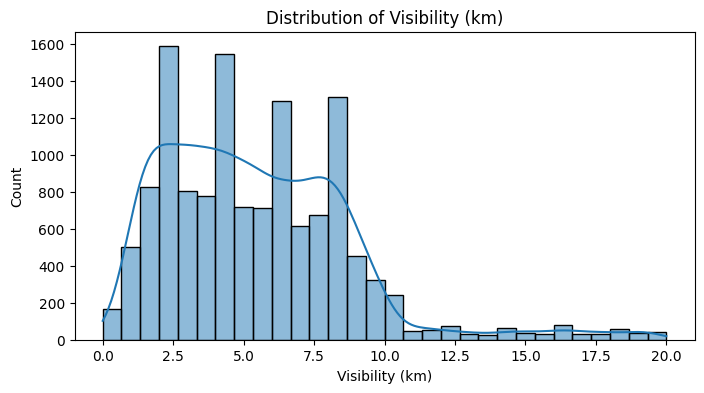

In [8]:
# Plot distributions of numerical features
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()

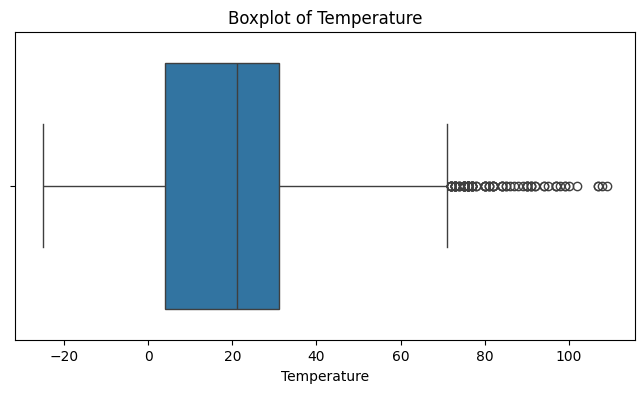

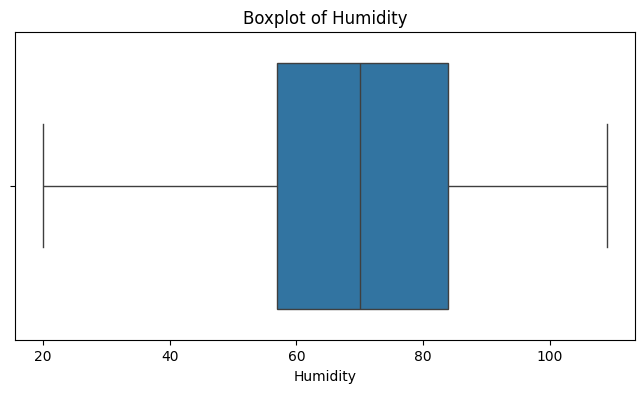

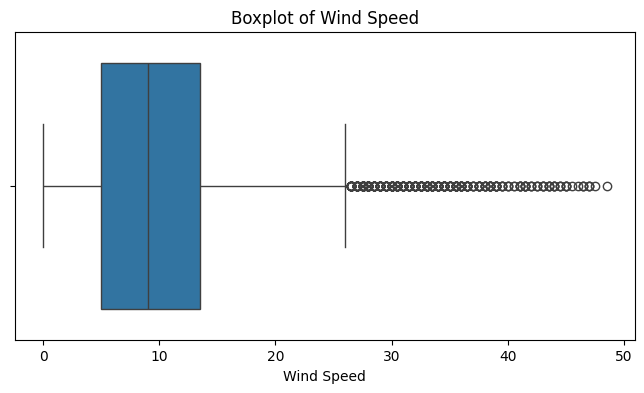

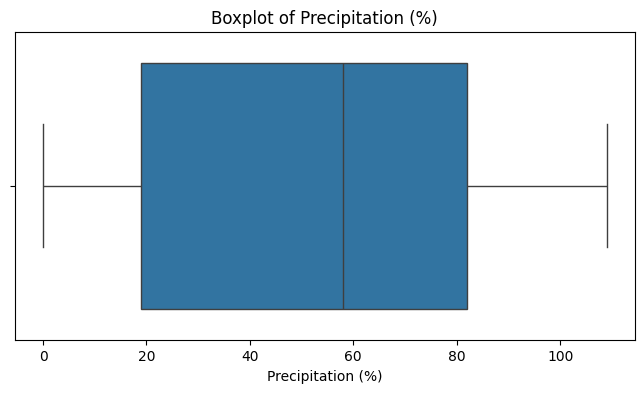

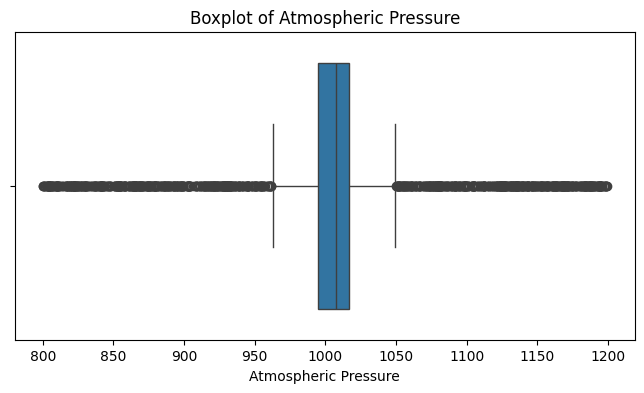

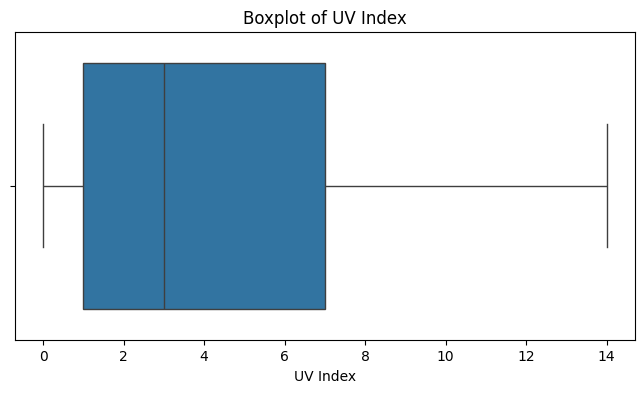

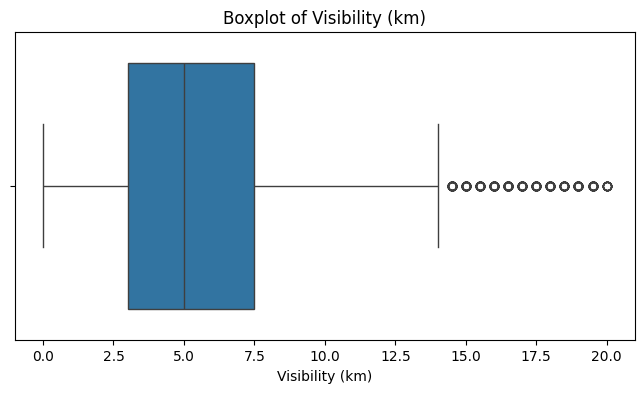

In [9]:
# Box plots to detect outliers
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

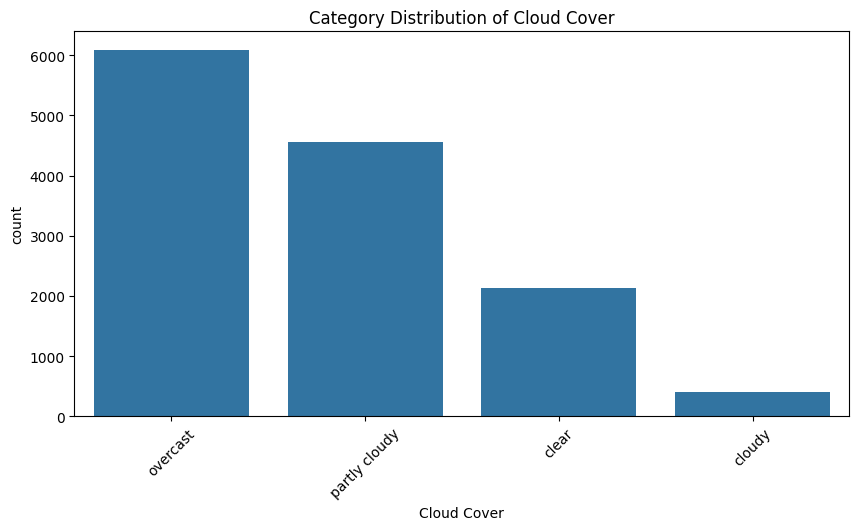

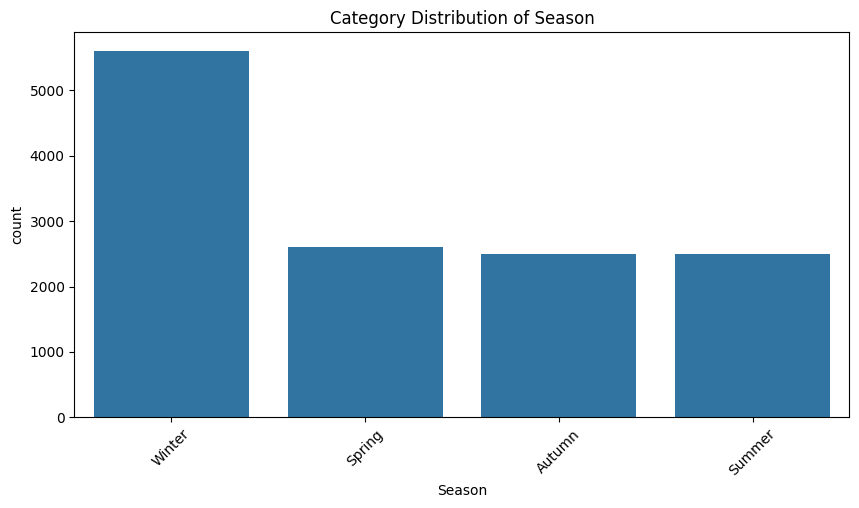

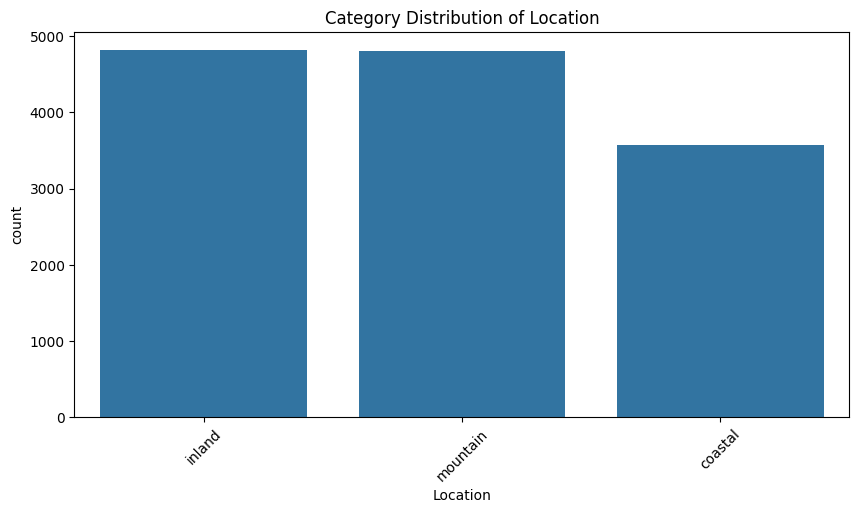

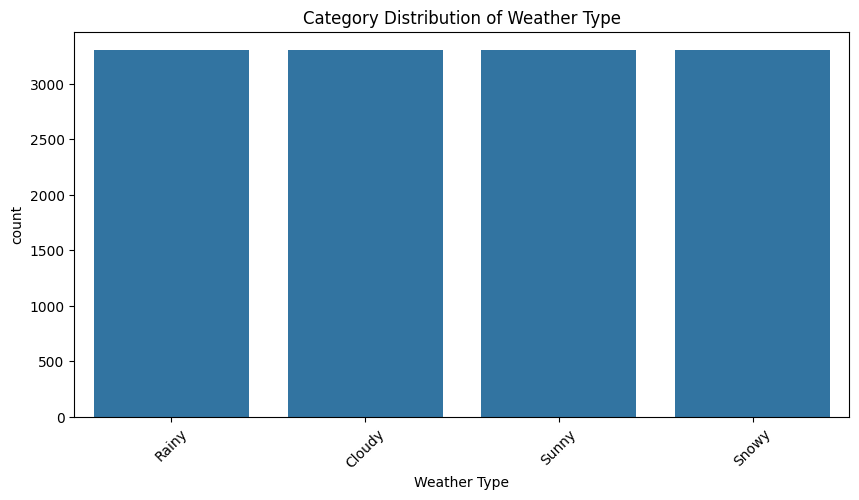

In [10]:
# Categorical feature analysis
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    sns.countplot(x=df[col], order=df[col].value_counts().index)
    plt.title(f'Category Distribution of {col}')
    plt.xticks(rotation=45)
    plt.show()

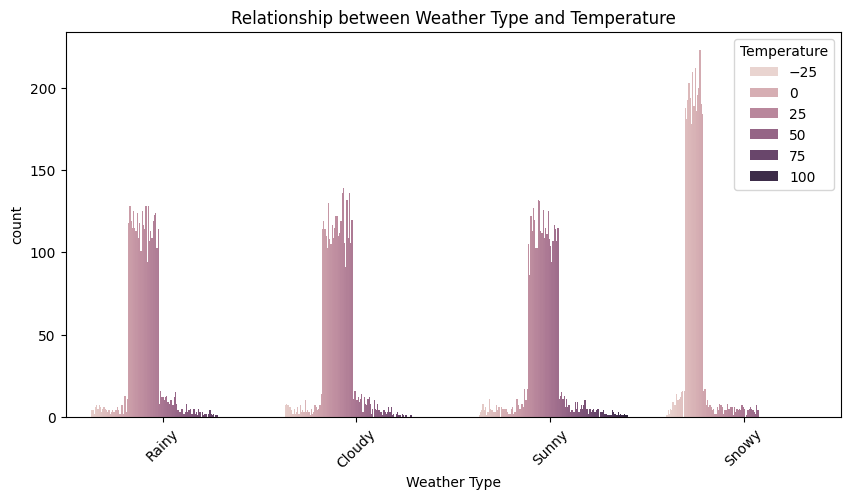

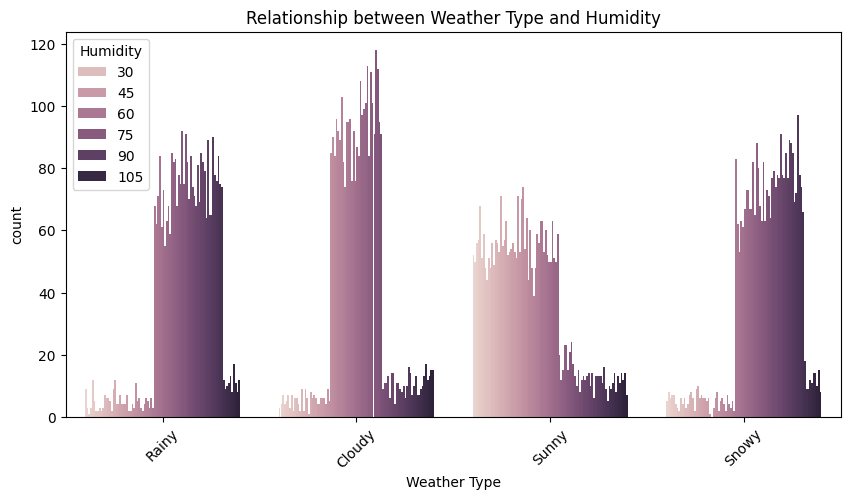

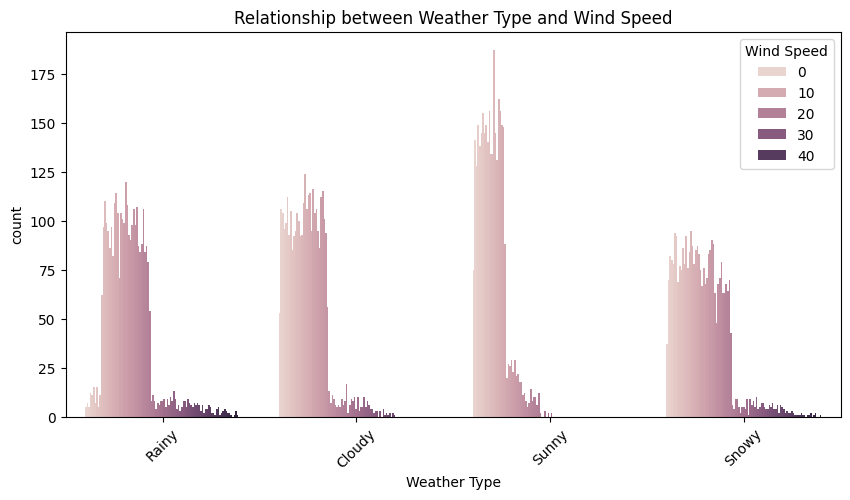

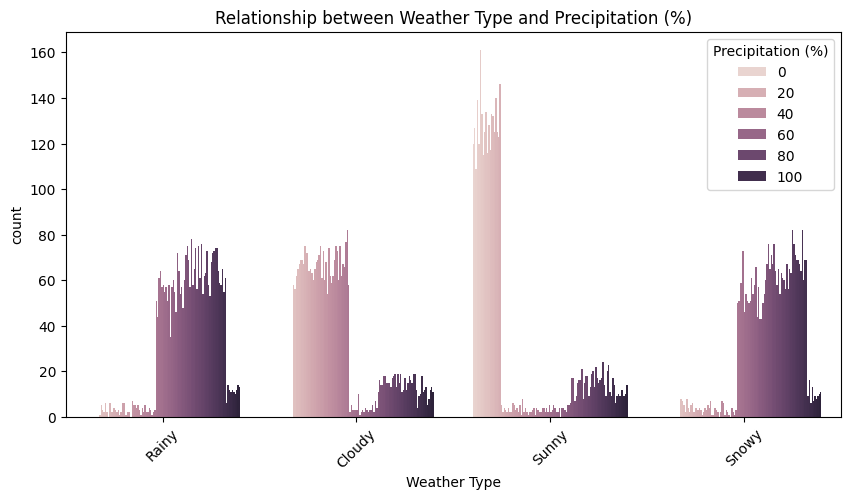

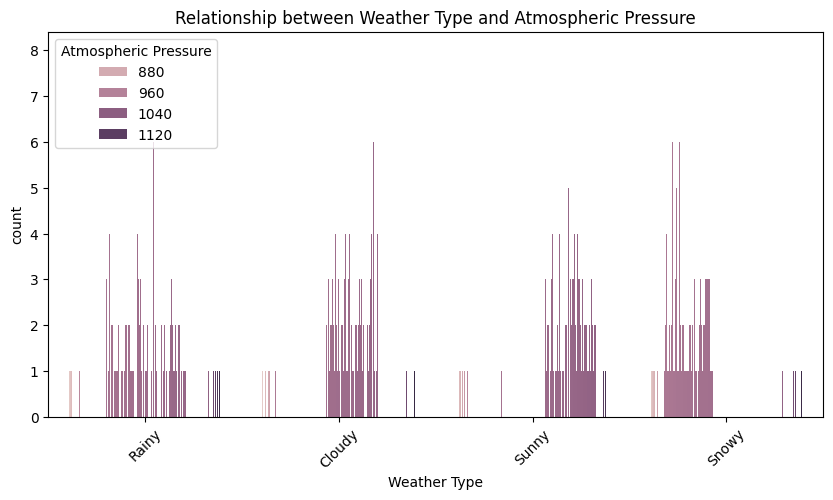

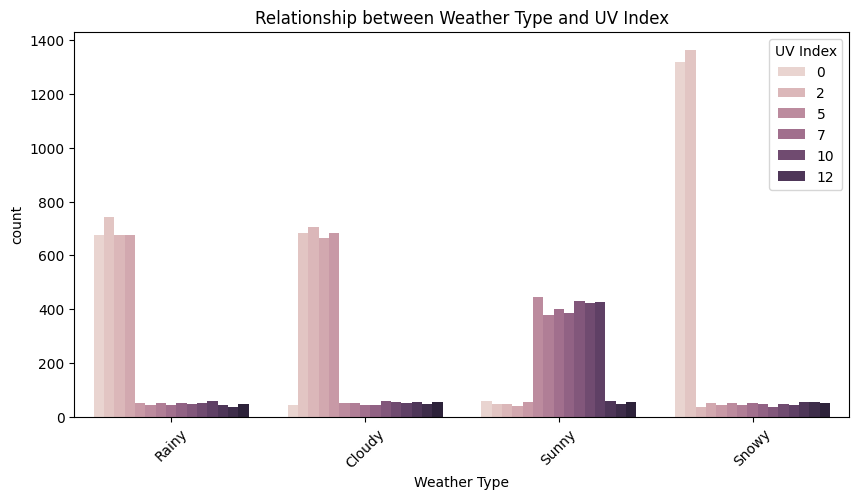

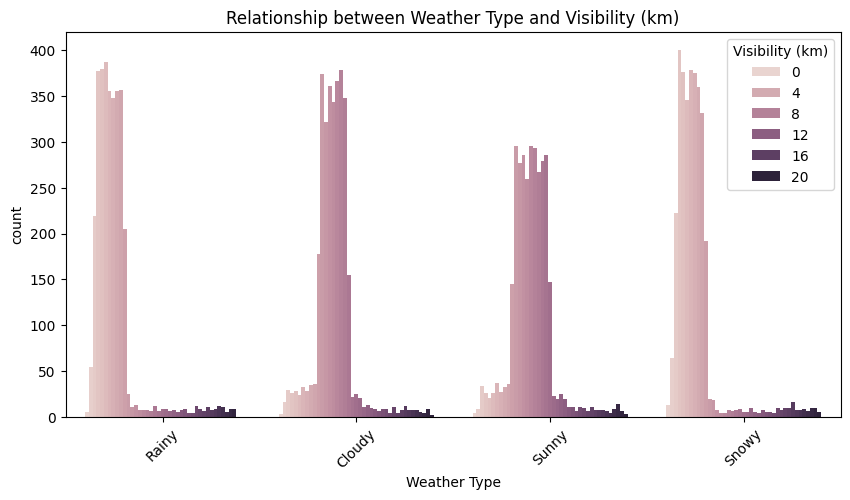

In [11]:
# Relationship between categorical and numerical features
for n_col in numeric_cols:
    for c_col in categorical_cols[3:]:
        plt.figure(figsize=(10, 5))
        sns.countplot(x=df[c_col], hue=df[n_col], order=df[c_col].value_counts().index)
        plt.title(f'Relationship between {c_col} and {n_col}')
        plt.xticks(rotation=45)
        plt.show()

# Classification

In [12]:
# Encode categorical features
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [13]:
# Define features and target for classification
X_classification = df.drop(columns=['Weather Type'])
y_classification = df['Weather Type']

In [14]:
# Split dataset into training and testing sets for classification
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_classification, y_classification, test_size=0.2, random_state=42)

In [15]:
# Standardize numerical features
scaler = StandardScaler()
X_train_c = scaler.fit_transform(X_train_c)
X_test_c = scaler.transform(X_test_c)

In [16]:
# Define classifiers
classifiers = {
    'Decision Tree': DecisionTreeClassifier(),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(),
    'Logistic Regression': LogisticRegression(),
    'Naive Bayes': GaussianNB(),
    'LDA': LinearDiscriminantAnalysis(),
    'SGD': SGDClassifier()
}

In [17]:
# Train and evaluate classifiers
accuracy_results = {}
for name, clf in classifiers.items():
    clf.fit(X_train_c, y_train_c)
    y_pred_c = clf.predict(X_test_c)
    accuracy = accuracy_score(y_test_c, y_pred_c)
    accuracy_results[name] = accuracy
    print(f'{name} Accuracy: {accuracy:.4f}')

Decision Tree Accuracy: 0.9095
KNN Accuracy: 0.8917
SVM Accuracy: 0.9068
Logistic Regression Accuracy: 0.8485
Naive Bayes Accuracy: 0.8629
LDA Accuracy: 0.8352
SGD Accuracy: 0.8383


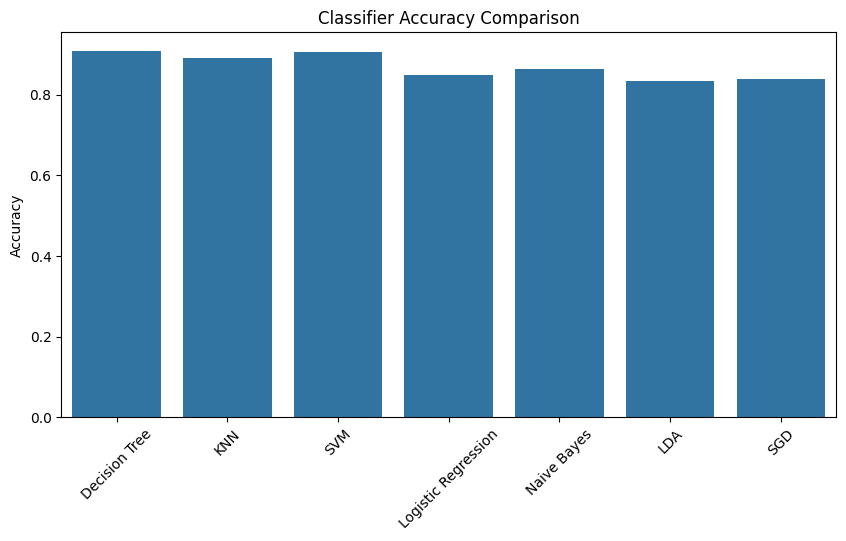

In [18]:
# Compare accuracy scores
plt.figure(figsize=(10, 5))
sns.barplot(x=list(accuracy_results.keys()), y=list(accuracy_results.values()))
plt.title('Classifier Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.show()

# Regression

In [19]:
# Define features and target for regression
X_regression = df.drop(columns=['Precipitation (%)'])
y_regression = df['Precipitation (%)']

In [20]:
# Split dataset into training and testing sets for regression
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_regression, y_regression, test_size=0.2, random_state=42)

In [21]:
# Standardize numerical features
X_train_r = scaler.fit_transform(X_train_r)
X_test_r = scaler.transform(X_test_r)

In [22]:
# Define regressors
regressors = {
    'Decision Tree': DecisionTreeRegressor(),
    'KNN': KNeighborsRegressor(),
    'SVM': SVR(),
    'Linear Regression': LinearRegression()
}

In [23]:
# Train and evaluate regressors
rmse_results = {}
for name, reg in regressors.items():
    reg.fit(X_train_r, y_train_r)
    y_pred_r = reg.predict(X_test_r)
    rmse = sqrt(mean_squared_error(y_test_r, y_pred_r))
    rmse_results[name] = rmse
    print(f'{name} RMSE: {rmse:.4f}')

Decision Tree RMSE: 20.4602
KNN RMSE: 17.2668
SVM RMSE: 16.8632
Linear Regression RMSE: 23.0580


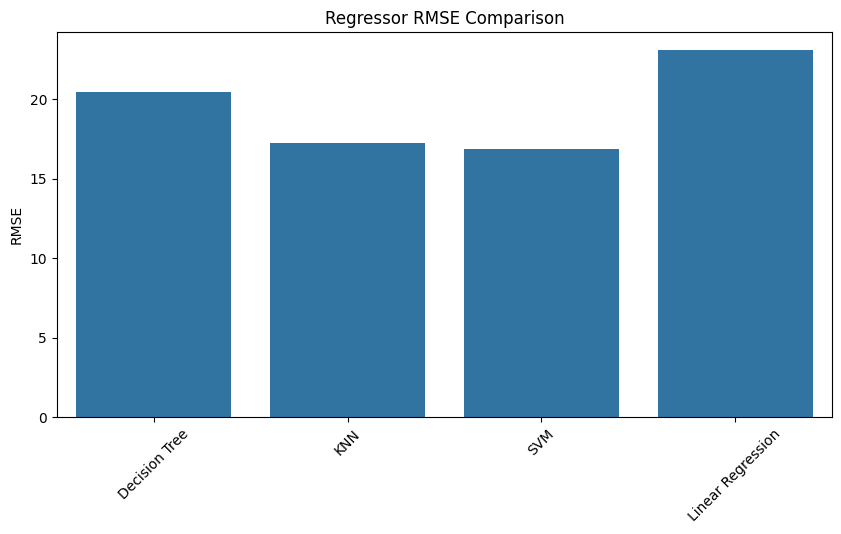

In [24]:
# Compare RMSE scores
plt.figure(figsize=(10, 5))
sns.barplot(x=list(rmse_results.keys()), y=list(rmse_results.values()))
plt.title('Regressor RMSE Comparison')
plt.ylabel('RMSE')
plt.xticks(rotation=45)
plt.show()